In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()

  Activating project at `d:\TFM code`


In [11]:
include("module/new_purified.jl")
nothing

MPS evo (r=50) 100%|█████████████████████████████████████| Time: 0:00:11
MPS evo (r=100) 100%|████████████████████████████████████| Time: 0:00:22
[ Info: Saved animation to d:\TFM code\NoteBook\Plots\complete_plotevo.gif


asdasd

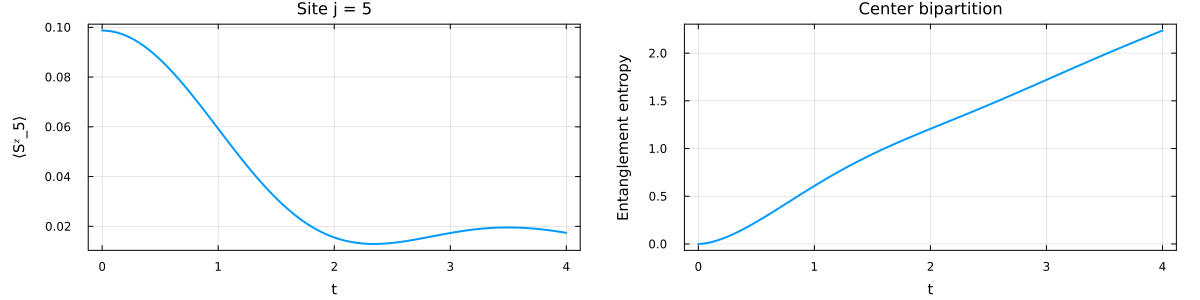

Plots.AnimatedGif("d:\\TFM code\\NoteBook\\Plots\\complete_plotevo.gif")
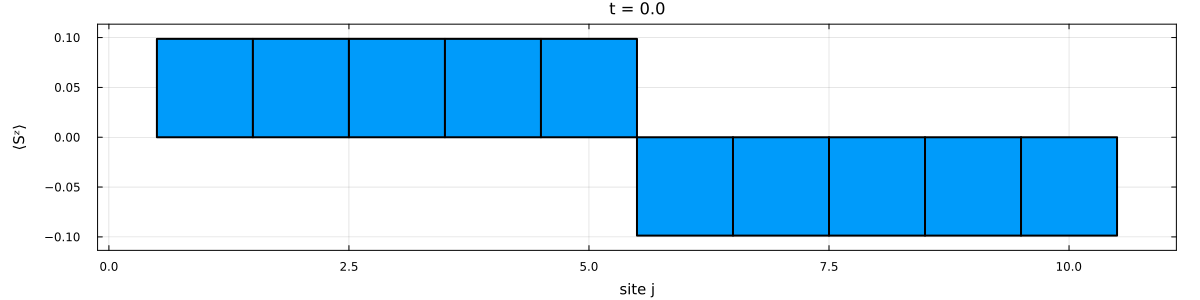

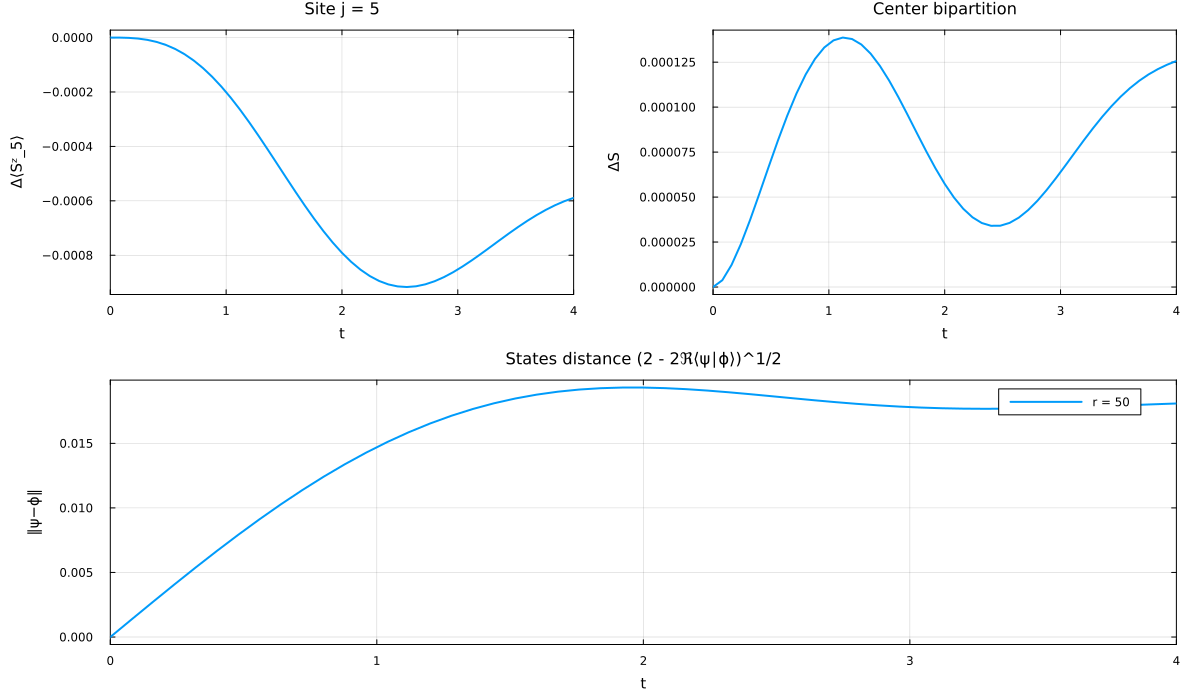

In [ ]:
N = 10 # Number of physical sites
mu = 0.4
t = 4.0
rv = [50, 100]

# 1. Generate the purified state
psi, sitesP, sitesA, sitesPA = purified_domainwall(N, mu) 

# 2. Pass `sitesP` (the physical sites) to the evolution function. 
# It will use `sitesP` to build the gates, but it will evolve `psi` (which lives on `sitesPA`).
All_evos = Diff_trotter_r(sitesP, psi, t, rv; cutoff=1e-10, doprint=false, showprogress=true)

# 3. Plotting
complete_plots(N, t, t/rv[end], All_evos)
nothing

In [24]:
pidx(i) = Int(2*i - 1)

Sz_i = expect(psi, "Sz"; sites=pidx(N/2-1))  # ⟨ψ| Sz(pos) |ψ⟩ (scalar)

@show inner(psi, psi)
@show Sz_i ≈ 0.5*tanh(mu/2)
nothing

inner(psi, psi) = 1.0000000000000022 + 0.0im
Sz_i ≈ 0.5 * tanh(mu / 2) = true


MPS evo (r=10) 100%|█████████████████████████████████████| Time: 0:00:41
MPS evo (r=25) 100%|█████████████████████████████████████| Time: 0:01:39
MPS evo (r=50) 100%|█████████████████████████████████████| Time: 0:03:19
MPS evo (r=250) 100%|████████████████████████████████████| Time: 21:30:42
MPS evo (r=1000) 100%|███████████████████████████████████| Time: 0:51:11
[ Info: Saved animation to d:\TFM code\NoteBook\Plots\complete_plotevo.gif


asdasd

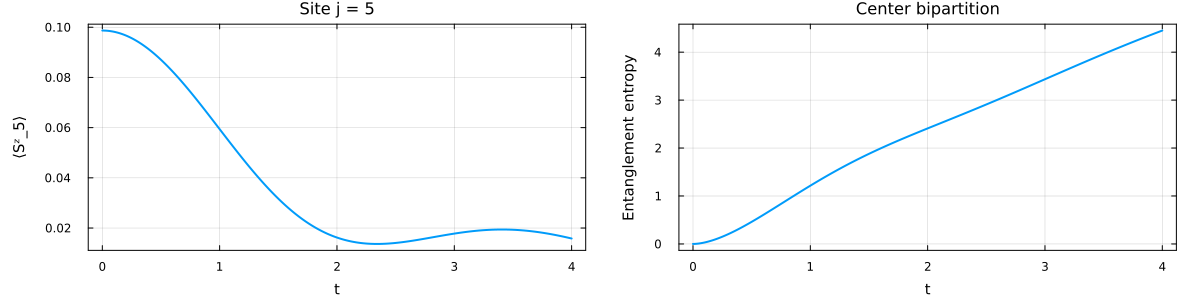

Plots.AnimatedGif("d:\\TFM code\\NoteBook\\Plots\\complete_plotevo.gif")
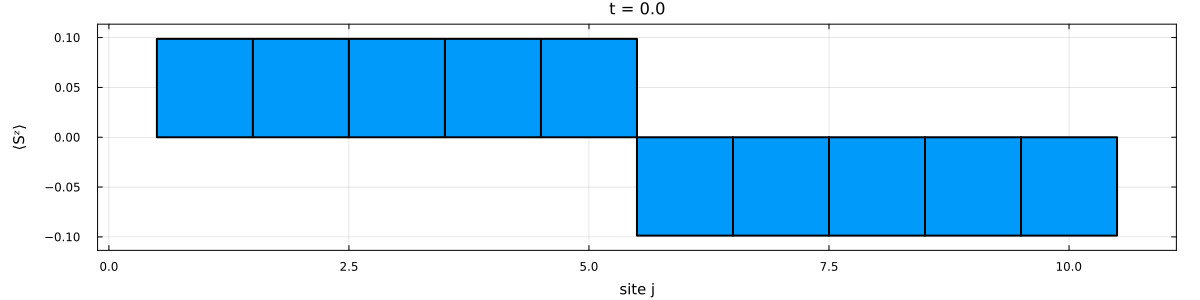

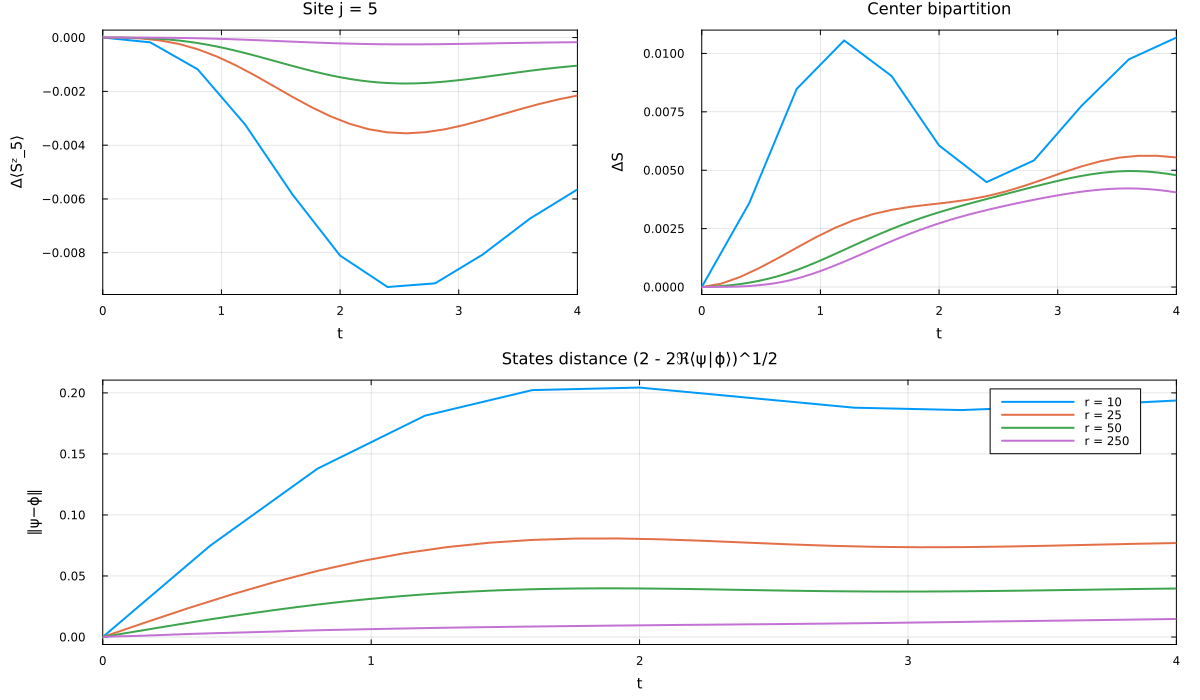

In [27]:
# ============== State Evolution ============= #
t = 4.0 # total time of the Evolution
rv   = [10, 25, 50, 250, 1000]
h = [nothing] # h vector
All_evos = Diff_trotter_r(sitesP, psi,  t,  rv; h = h, per = true, cutoff = 1e-10, doprint = false, showprogress = true)

# ============ Plots & Animations ============ #
tau = t/rv[end]
complete_plots(N, t, tau, All_evos)
nothing